# Key components and reactions

## Background and task
We consider the hydrogenation of $CO$ and $CO_2$ into $CH_4$ using Ni-based catalysts. The following reactions $R_j$ will take place:

\begin{align}
CO + 3H_2 &\rightleftharpoons CH_4 + H_2O\\
CO_2 + 4H_2 &\rightleftharpoons CH_4 + 2H_2O\\
CO + H_2O &\rightleftharpoons CO_2 + H_2
\end{align}

Detailed information can be found here:
* Ullmann's Encyclopedia: https://doi.org/10.1002/14356007
* General review: https://doi.org/10.1016/j.fuel.2015.10.111
* Thermodynamics: https://doi.org/10.1039/C2RA00632D

The task is to determine the key components and reactions, as well as the reaction extent.

## Matrix of stoichiometric coefficients

### Setup the matrix
First, we setup the matrix of stoichiometric coefficients $\underline{N}$ with reactions $R_j$ alligned in columns and components $A_i$ in lines. The transposed matrix is thus defined as:

\begin{equation}
  \underline{N}^T=
    \begin{bmatrix}
          & CO & CO_2 & CH_4 & H_2 & H_2O\\
      R_1 & -1 & 0    & 1    & -3  & 1\\
      R_2 & 0  & -1   & 1    & -4  & 2\\
      R_3 & -1 & 1    & 0    &  1  & -1
    \end{bmatrix}
\end{equation}

The rank of the matrix of stoichiometric coefficients $R_N$ gives the number of key components and reactions.

### Python implementation
Import of Numpy is required. Furthermore, the index of a vector starts at 0 in Python and therefore $j_{Python} =  j-1$ has to be considered. The code is then implemented as follows:

In [1]:
import numpy as np # import of numpy
from numpy.linalg import matrix_rank

# define matrix of stoichiometric coefficients
N_stoich = np.array([[-1,  0,  -1],  # CO
                     [ 0, -1,   1],  # CO2
                     [ 1,  1,   0],  # CH4
                     [-3, -4,   1],  # H2
                     [ 1,  2,  -1]]) # H2O
# N_stoich.T is the transposed matrix

# determination of the rank of the matrix of stoichiometric coefficients
N_stoich_rank = matrix_rank(N_stoich)
print(r'Rank:',N_stoich_rank) # display key result

Rank: 2


 ### Results discussion
 
The rank is $R_N=2$, which means that two key reactions and components are sufficient to describe the reaction extent based on stoichiometry. According to the order of components and reactions chosen for the matrix of stoichiometric coefficients, $CO$ and $CO_2$ are the key components. Rearranging the matrix allows to chose other key components and reactions. This is meaningful, in order to chose components that are easy to measure.

**Important**: The rank needs to be checked again for the chosen set of key reactions and components, based on the respective simplified matrix of stoichiometric coefficients. Only if the rank is identical to that of the full matrix, the chosen set is representing the key components and reactions.

## Determination of the reaction extent

### Material balance

We now use the definition of the reaction extent $\xi_j$ for performing the molar balance of component $A_i$ in matrix notation for continuous systems:

\begin{align}
  \underline{\dot n}_{out}-\underline{\dot n}_{in} =\Delta\underline{\dot n} = \underline{N}\,\underline{\dot\xi}
\end{align}

The conversion $\Delta\dot n_i$ is defined as the difference between inlet and outlet molar flow rate ($\dot n_{i,in}$ and $\dot n_{i,out}$).

Using the known Rank $R_N$, we can now split the matrix of stoichiometric coefficients into submatrices:

\begin{equation}
  \underline{N}=
    \begin{bmatrix}
      \underline{N}_{11} && \underline{N}_{12}\\
      &&\\
      \underline{N}_{21} && \underline{N}_{22}
    \end{bmatrix}%^1_2
\end{equation}

being $\underline{N}_{11}$ a square matrix of size $R_N$, which describes the stoichiometry of the key components in the key reactions. Therefore, $\underline{N}_{11}^{-1}$ exists. 

The implementation to Python is as follows:

In [2]:
# split of the matrix of stoichiometric coefficients
N_stoich_11 = N_stoich[0:N_stoich_rank, 0:N_stoich_rank] # square sub-matrix of size rank
N_stoich_21 = N_stoich[N_stoich_rank:N_stoich.shape[0], 0:N_stoich_rank]
N_stoich_12 = N_stoich[0:N_stoich_rank, N_stoich_rank:N_stoich.shape[1]]
N_stoich_22 = N_stoich[N_stoich_rank:N_stoich.shape[0], N_stoich_rank:N_stoich.shape[1]]

### Conversion and flow rates

The conversion can be split, as well, into the conversion of the key components $\Delta\underline{\dot n}_{1}$ and that of the non-key components $\Delta\underline{\dot n}_{2}$:

\begin{equation}
  \Delta\underline{\dot n}=
    \begin{bmatrix}
      \Delta\underline{\dot n}_{1}\\
      \\
      \Delta\underline{\dot n}_{2}
    \end{bmatrix}%^1_2
\end{equation}

The conversion of the key components should be known, e.g. from measurements, and the length of respective vector is $\Delta\underline{\dot n}_{1} = R_N$.
After some mathematical transformation, the conversion of the non-key components $\Delta\underline{\dot n}_{2}$ can be calculated according to:

\begin{equation}
  \Delta\underline{\dot n}_{2} = \underline{N}_{21}\,\underline{N}_{11}^{-1}\,\Delta\underline{\dot n}_{1}
\end{equation}

As an example we now assume that the following inlet molar flow rates (the components are also given in the second column for ease of understanding, though it is not correct mathematically):

\begin{equation}
  \underline{\dot n}_{in}=
    \begin{bmatrix}
      1.0 & CO\\ 4.0 & CO_2\\ 0.5 & CH_4\\ 17.0 & H2\\ 2.0 & H_2O
    \end{bmatrix}
    \frac{mol}{s}
\end{equation}

and the conversion of the key components is known:

\begin{equation}
  \Delta\underline{\dot n}_{1}=
    \begin{bmatrix}
      -0.9 & CO\\ \\-2.0 & CO_2
    \end{bmatrix}
    \frac{mol}{s}
\end{equation}

With these values the conversion of the non-key components and the outlet molar flow rates can be calculated based on the equations above. This is implemented as follows:

In [3]:
n_in = np.array([1.0, 4.0, 0.5, 17.0, 2.0]) # inlet molar flow rates in mol/s
Delta_n1 = np.array([-0.9, -2.0]) # measured conversion of key components in mol/s

Delta_n2 = np.matmul(np.matmul(N_stoich_21, np.linalg.inv(N_stoich_11)),Delta_n1) # conversion non-key components
print('conversion of non-key components in mol/s:',Delta_n2) # display key result

n_out =n_in + np.hstack((Delta_n1, Delta_n2)) # outlet molar flow rates of all components
print('outlet molar flow rates in mol/s:',n_out) # display key result

conversion of non-key components in mol/s: [  2.9 -10.7   4.9]
outlet molar flow rates in mol/s: [0.1 2.  3.4 6.3 6.9]


The conversion of the non-key components is now known:

\begin{equation}
  \Delta\underline{\dot n}_{2}=
    \begin{bmatrix}
      2.9 & CH_4\\ -10.7 & H_2 \\ 4.9 &H_2O
    \end{bmatrix}
    \frac{mol}{s}
\end{equation}

The outlet molar flow rates of all components are:

\begin{equation}
  \underline{\dot n}_{out}=
    \begin{bmatrix}
      0.1 & CO\\ 2.0 & CO_2\\ 3.4 & CH_4\\ 6.3 & H2\\ 6.9 & H_2O
    \end{bmatrix}
    \frac{mol}{s}
\end{equation}

The plausibility check of the results reveals that they are meaningful. For instance, the water conversion fits to the molar amount formed during $CO$ and $CO_2$ hydrogenation. $H_2$ is also consumed correctly, according to stoichiometry. Inlet and outlet molar flow rates also appear to be summed correctly and no mistake in signs is apparent.

### Reaction extent
Finally, the reaction extent can easily be calculated from the key components and key reactions, only, by solving a system of linear equations:

\begin{equation}
  \Delta\underline{\dot n}_1 = \underline{N}_{11}\,\underline{\dot\xi}
\end{equation}

Implemented to Python as follows:

In [4]:
rxn_ext = np.linalg.solve(N_stoich_11, Delta_n1) # solving linear equation system
print('reaction extent in mol/s:',rxn_ext) # display of key result

reaction extent in mol/s: [0.9 2. ]


The reaction extent of the key reactions, thus, amounts to:

\begin{equation}
  \underline{\dot \xi}=
    \begin{bmatrix}
      0.9 \\ \\2.0
    \end{bmatrix}
    \frac{mol}{s}
\end{equation}

The plausibility check reveals that the reaction extent corresponds to the conversion, but exhibits a positive sign, according to the definition. The obtained values are expected and thus appear correct.

## Conclusions

It has to be mentioned that only the key reactions can be considered here, since the conversion of the key components is given, only. In other words the minimum required information is provided in the example, specifically the conversion of the key components. Thus, the available knowledge does allow to quantify key components and reactions only. However, the obtained results are suffient to completely describe the system.

In real experiments, one would try to measure more than just the minimum number of components. The additional information gained than also allow to check the calculated reaction extent and to deduce, if unkown side reactions can be ruled out.

In other words, considering key components and reactions, only, eventually assumes that the system is completely known and that no measurement errors occure. This is identical to the assumption that the balance is met. Additional information, e.g. by measuring more components than the number of key components, allows to validate this assumption, which is of particular importance for evaluation of experimental data. This allows to quantify measurement errors or to identify real affects falsifying the conclusions. For instance, in our own experiments on methanation we always measure $CO$, $CO_2$ and $CH_4$, in order to check the carbon balance.

# Chemical reaction equilibrium

## Background and task

We consider the ammonia synthesis according to the following reaction

\begin{equation}
  N_2 + 3H_2 \rightleftharpoons 2NH_3
\end{equation}

The task is to calculate the reaction extent in equilibrium for different temperatures $T$ and pressures $p$. The inlet molar flow rates $\dot n_i$ of all components $A_i$ may also vary.

## Thermodynamic properties

First, the thermodynamic properties are obtained from NIST (https://webbook.nist.gov/chemistry/) and implemented to a function in Python. Therefore, the following Shomate equations are used for heat capacity ($c_p$ in $J mol^{-1} K^{-1}$), standard enthalpy ($H$ in $kJ mol^{-1}$) and standard entropy ($S$ in $J mol^{-1} K^{-1}$):

\begin{align}
  c_p &= A + B\,\vartheta + C\,\vartheta^2 + D\,\vartheta^3 
        + E\,\vartheta^{-2}\\
  H-H(298.15 K) = \Delta_fH - \Delta_fH(298.15K)&= A\,\vartheta + \frac{B\,\vartheta^2}{2} 
        + \frac{C\,\vartheta^3}{3}
        + \frac{D\,\vartheta^4}{4} - E\,\vartheta^{-1} + F - H\\
  S &= A\,\ln(\vartheta) + B\,\vartheta + \frac{C\,\vartheta^2}{2} 
        + \frac{D\,\vartheta^3}{3}
        - \frac{E\,\vartheta^{-2}}{2} + G
\end{align}

These equations require the dimensionless temperature $\vartheta = \frac{T}{1000 K}$. The parameters are given as follows valid in the temperature range between $298$ and $1000 K$ (rounded to 4 digits, for more accuracy check NIST).

\begin{equation}
    \begin{matrix}
      & A & B & C & D & E & F & G & H\\
      H_2 & 33.07 & -11.36 & 11.43 & -2.773 & -0.1586 & -9.981 & 172.7 & 0.0
    \end{matrix}
\end{equation}

Implementation of the respective function in Python (this function can be called from the Python program, if needed) was achieved as follows:

In [5]:
# define function with arguments temperature and name of component
def prop_thermo(T, comp):
    results = np.empty(3) # generate empty vector of required size
    t=T/1000 # define the dimensionless temperature required
    # define the Shomate equations
    fun_cp_NIST = np.array([t**0, t, t**2, t**3, t**-2, 0, 0, 0])
    fun_H_NIST = np.array([t, t**2/2, t**3/3, t**4/4, -t**-1, 1, 0, -1])
    fun_S_NIST = np.array([np.log(t), t, t**2/2, t**3/3, -t**-2/2, 0, 1, 0])
    # assign parameters of the Shomate equation to components
    if comp == 0 or comp == 'NH3': #
        PhysProp_param_NIST = np.array([20.0, 49.77, -15.38, 1.921, 0.1892, -53.31, 203.9, -45.90])
    elif comp == 1 or comp == 'H2': #
        PhysProp_param_NIST = np.array([33.07, -11.36, 11.43, -2.773, -.1586, -9.981, 172.7, 0])
    elif comp == 2 or comp == 'N2': #
        PhysProp_param_NIST = np.array([28.99, 1.854, -9.647, 16.64, 0.0, -8.672, 226.4, 0.0])
    else:
        PhysProp_param_NIST = np.array([0, 0, 0, 0, 0, 0, 0, 0])
    # multiply set of parameters to Shomate equation
    results[0] = fun_cp_NIST.dot(PhysProp_param_NIST) # heat capacity
    results[1] = (PhysProp_param_NIST[-1] + fun_H_NIST.dot(PhysProp_param_NIST))*1000 # enthalpy of formation
    results[2] = fun_S_NIST.dot(PhysProp_param_NIST) # entropy
    return results
# call of the function for T = 25°C and NH3 to compare with tabulated data
print('vector of heat capacity, enthalpy and entropy for ammonia:',prop_thermo(25+273, 'NH3')) # display of key result for check

vector of heat capacity, enthalpy and entropy for ammonia: [ 3.56470257e+01 -4.59068945e+04  1.92787000e+02]


## Chemical thermodynamics

### Equilibrium constant from thermodynamic data

The thermodynamic properties of the reaction can be calculated using the stoichiometric coefficient, as for the example of reaction enthalpy $\Delta_RH$:

\begin{equation}
  \Delta_RH(T) = \sum_i \nu_i\,\Delta_fH_i(T)
\end{equation}

Therefore the thermodynamic properties at temperature $T$ are used, which are provided by the Shomate equations above, already. 

The Gibbs free reaction enthalpy $\Delta_RG$ can be calculated by either:

\begin{equation}
  \frac{\Delta_RG(T)}{T} = 
      \frac{\Delta_RG(T_{ref})}{T_{ref}}
      - \int_{T_{ref}}^T \frac{\Delta_RH(T)}{T^2}dT
\end{equation}

or via the reaction entropy $\Delta_RS$:

\begin{align}
  \Delta_RG(T) &= \Delta_RH(T)-T\,\Delta_RS(T)
\end{align}

The thermodynamic equilibrium constant $K^°$ can now be calculated from the thermodynamic data via:

\begin{equation}
  K^°(T) =\exp\left(-\frac{\Delta_RG(T)}{R\,T}\right)
\end{equation}

The way via entropy is implemented in Python by the following function:

In [6]:
# define function with argument temperature
def rxn_data(T):
    res = np.empty(5) # generate empty vector of required size
    # call the function on thermodynamic properties for all components
    data_NH3 = prop_thermo(T, 'NH3')
    data_N2 = prop_thermo(T, 'N2')
    data_H2 = prop_thermo(T, 'H2')
    # use stoichiometry to calculate the thermodynamic properties of the reaction
    res[0] = 2*data_NH3[0] - data_N2[0] - 3*data_H2[0] # reaction heat capacity
    res[1] = 2*data_NH3[1] - data_N2[1] - 3*data_H2[1] # reaction enthalpy
    res[2] = 2*data_NH3[2] - data_N2[2] - 3*data_H2[2] # reaction entropy
    res[3] = res[1] - T*res[2] # reaction Gibbs enthalpy
    res[4] = np.exp(-res[3]/(8.3145*T)) # reaction equilibrium constant
    return res
# call the function for T = 25°C to compare with tabulated data
print('vector with heat capacity, enthalpy, entropie and Gibbs enthalpy of the reaction, and thermodynamic equilibrium constant:',rxn_data(25+273)) # display of key result for check

vector with heat capacity, enthalpy, entropie and Gibbs enthalpy of the reaction, and thermodynamic equilibrium constant: [-4.43533344e+01 -9.18019203e+04 -1.97962344e+02 -3.28091418e+04
  5.63352660e+05]


### Equilibrium constant from law of mass action

Based on the law of mass action several equilibrium constants can be defined, from which der thermodynamic ($K^°$) and that with respect to molar fraction ($K_x$) are used here:

\begin{align}
  K^° &= \prod_i\left(\frac{p_i}{p^°}\right)^{\nu_i}\\
  K_x &= \prod_i x_i^{\nu_i}
\end{align}

With the molar fraction $x_i$ both constants can be related to each other for ammonia synthesis:

\begin{equation}
  K_x=\frac{x^2_{NH_3}}{x^3_{H_2}\,x_{N_2}}=K^°\,\left(\frac{p}{p^°}\right)^2
\end{equation}

Now, the dependency of the equilibrium constant from $T$ (provided in $K^°$) and $p$ should be studied. The implementation in Python is as follows:

<>:18: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\,'
C:\Users\Tuana\AppData\Local\Temp\ipykernel_11868\2277597056.py:18: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel("$K_x\,/\,1$")


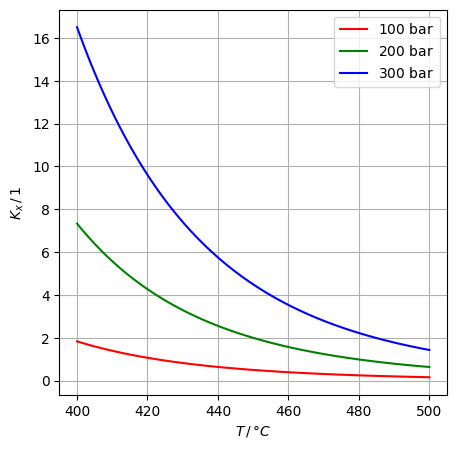

In [7]:
import matplotlib.pyplot as plt # import of matplotlib

# define vectors for typical ranges of T and p
T = np.linspace(400+273, 500+273, 100) # temperature in K
p = np.array([100, 200, 300]) # total pressure in bar

K_x = np.empty([p.shape[0],T.shape[0]]) # generate empty vector of required size
for TT in range(T.shape[0]): # vary the temperature within the given range
    # at each single temperature
    rxn_data_get = rxn_data(T[TT]) # call the function for thermodynamic data of the reaction 
    K_eq = rxn_data_get[-1] # the last element in the results vector provides the thermodynamic equilibrium constant
    K_x[:,TT] = K_eq*np.power(p,2) # calculate K_x at each temperature for all pressures

# generate the plot
plt.figure(figsize=(5, 5))
plt.grid()
plt.xlabel(r"$T\,/\,°C$")
plt.ylabel("$K_x\,/\,1$")
plt.plot(T[:]-273, K_x[0,:], 'r-', label="$100$ bar")
plt.plot(T[:]-273, K_x[1,:], 'g-', label="$200$ bar")
plt.plot(T[:]-273, K_x[2,:], 'b-', label="$300$ bar")
plt.legend(loc='best')
plt.show()

## Stoichiometry and reaction extent



### Material balance

The molar flow rates of component $A_i$ at the inlet $\dot n_{i,in}$ and at the outlet $\dot n_{i,out}$ can be related by the reaction extent $\xi$:

\begin{equation}
  \dot n_{i,out} = \dot n_{i,in} + \nu_i\,\xi
\end{equation}

The overall molar flow rate at the outlet $\dot n_{out}=\sum_i \dot n_{i,out}$ can be expressed by that at the inlet $\dot n_{in}=\sum_i \dot n_{i,in}$ via:

\begin{align}
  \dot n_{out} &= \dot n_{in} + \xi\,\sum_i \nu_i
\end{align}

For ammonia synthesis this gives

\begin{align}
  \dot n_{out} &= \dot n_{in} -2\, \xi
\end{align}

The molar fractions $x_{i,out}$, relevant for calculating the equilibrium constant $K_x$ via the law of mass action assuming a well mixed reactor, are defined as:

\begin{align}
  x_{i,out} &= \frac{\dot n_{i,out}}{\dot n_{out}}=\frac{\dot n_{i,in} + \nu_i\,\xi}{\dot n_{in} -2\, \xi}
\end{align}

### Calculation of the reaction extent and composition in equilibrium

For calculation of the reaction extent $\xi$ the root of the following function is derived numerically (see law of mass action above):

\begin{equation}
  0 = K_x\,x^3_{H_2,out}\,x_{N_2,out} - x^2_{NH_3,out}
\end{equation}

The equilibrium constant $K_x$ is derived from thermodynamics, while the molar fractions $x_{i,out}$ depend on the reaction extent $\xi$. The implementation in Python is as follows:

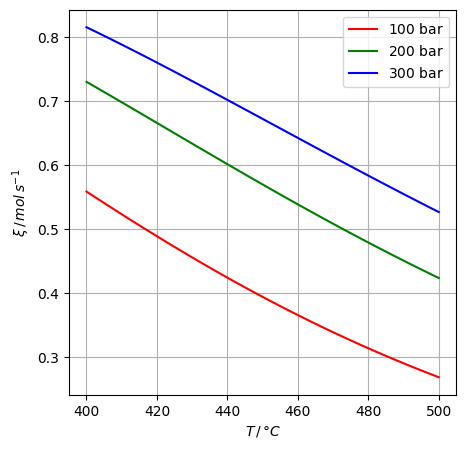

In [8]:
from scipy.optimize import fsolve # import function for root finding
from scipy.optimize import root ## import of the numerical solver function

# define function for calculation of outlet molar fraction with reaction extent 
# and inlet molar flow rates as arguments
def composition(xi,n_in):
    x = np.empty(3) # generate empty vector of required size
    x[0] = (n_in[0] - xi)/(np.sum(n_in)-2*xi) # N2
    x[1] = (n_in[1] - 3*xi)/(np.sum(n_in)-2*xi) # H2
    x[2] = (n_in[2] + 2*xi)/(np.sum(n_in)-2*xi) # NH3
    return x

# define function for calculation of reaction extent; this function describes 
# the non-linear equation to be solved to derive the reaction extent
def rxn_ext(xi,n_in, T, p):
    x = composition(xi,n_in) # get the outlet composition
    rxn_data_get = rxn_data(T) # get thermodynamic data of the reaction 
    K_eq = rxn_data_get[-1] # get the thermodynamic equilibrium constant
    K_x = K_eq*np.power(p,2) # calculate the equilibrium constant
    # definition of the non-linear equation for reaction extent as required for root finding
    res = K_x*np.power(x[0],1)*np.power(x[1],3) - np.power(x[2],2)
    return res

n_in = np.array([1, 5, 0]) # set inlet molar flow rates as example
xi = np.empty([p.shape[0],T.shape[0]]) # generate empty matrix of required size
for TT in range(T.shape[0]): # vary temperature; range given above
    for pp in range(p.shape[0]): # vary pressure; range given above
        # call root finding algorithm with syntax in brackets: 
        # (function to be solved, guess, args=(arguments required by function)) 
#        xi[pp,TT] = fsolve(rxn_ext,1,args=(n_in,T[TT],p[pp])) # variant via fsolve
        # (function to be solved, guess, args=(arguments required by function), method) 
        # results is of data type OptimizeResult, we take 'x' out from that data type
        xi[pp,TT] = root(rxn_ext,1,args=(n_in,T[TT],p[pp]),method='anderson').x # variant via root

# plot results
plt.figure(figsize=(5, 5))
plt.grid()
plt.xlabel(r"$T\,/\,°C$")
plt.ylabel(r"$\xi\,/\,mol\,s^{-1}$")
plt.plot(T[:]-273, xi[0,:], 'r-', label="$100$ bar")
plt.plot(T[:]-273, xi[1,:], 'g-', label="$200$ bar")
plt.plot(T[:]-273, xi[2,:], 'b-', label="$300$ bar")
plt.legend(loc='best')
plt.show()

The reaction extent decreases with increasing temperature, since ammonia synthesis is an exothermic reaction. Furthermore, it inreases with increasing pressure, since the reaction is associated with contraction of the molar amount ($\sum_i \nu_i<0$).

For a given temperature, pressure and inlet flow rate the outlet composition can be calculated as follows. First, the reaction extent is calculated under these conditions with the functions defined previously, which requires to solve the non-linear algebraic equation. Afterwards, the composition can be calculated using previously defined functions, as well. 

In [9]:
# numerical example for one specific operation point
n_in = np.array([1, 5, 0]) # inlet molar flow rate
T = 450+273 # temperatur in K
p = 100 # pressure in bar
# apply previously defined function
#xi = fsolve(rxn_ext,1,args=(n_in,T,p)) # calculate reaction extent
xi = root(rxn_ext,1,args=(n_in,T,p),method='anderson').x # calculate reaction extent
x = composition(xi,n_in) # calculate composition
print('outlet molar fractions / 1:',x) # display results on composition

outlet molar fractions / 1: [0.11629026 0.73258052 0.15112922]


The results at $450\,°C$ and $100\,bar$ reveal significant limitation of the reaction by chemical equilibrium, which becomes apparent from the relatively high residual fraction in $N_2$.

### Calculation of the equilibrium yield

In order to calculate the yield the outlet molar flow rates have to be calculated first, since the total molar amount is changing with reaction extent. This can be done by:

\begin{align}
  \dot n_{i,out}&=x_{i,out} \,\dot n_{out} =
  x_{i,out} \,(\dot n_{in} -2\, \xi)
\end{align}

The $NH_3$ yield $Y$ with respect to $N_2$ feed can be calculated as follows

\begin{equation}
  Y = \frac{\nu_{N_2}}{\nu_{NH_3}}\frac{\dot n_{NH_3,in}-\dot n_{NH_3}}{\dot n_{N_2,in}}
\end{equation}

These equations are implemented to Python as follows:

In [10]:
n_out = composition(xi,n_in)*(np.sum(n_in)-2*xi)
Y = -1/3*(n_in[2]-n_out[2])/n_in[0]
print('outlet molar flow rates / mol/s:',n_out) # display outlet molar flow rates
print('ammonia yield / 1:', Y) # display yield

outlet molar flow rates / mol/s: [0.6061366  3.81840981 0.78772679]
ammonia yield / 1: 0.2625755978817502


It can be seen that the equilibrium yield is very limited. Importantly, one has to consider that $H_2$ is feed in significant stoichiometric excess for the example, which appears not sufficient to reach a yield close to unity. Furthermore, it has to be emphasized that reaching equilibrium requires infinite residence times and thus infinite reactor volumes. Consequently, the equilibrium yield cannot be achieved in real reactors, but exhibits the upper bound, instead. The realistic yields may thus be significantly smaller, depending on reactor design and operation.

# Assignment

## General comments

The text and code above is intended to provide you with the subject-specific background to the assignment, the principle approach to the solution and working code examples. You do **not** have to reproduce the background and the equations. Instead, focus on the adaptions you made to the approach and the code in order to solve the assignment. Furthermore, you may extent the depth of the result discussion.

The code is intended to provide you a working basis. It is therefore tested to work, but is not optimized. So, feel free to provide improved coding, if you like. You should focus on the chemical reaction engineering dimension of the assignment, though.

## Use of AI tools in this assignment

The use of AI tools (e.g. ChatGPT, Claude, Gemini, GitHub Copilot, Perplexity) is **explicitly permitted**, but must be reflected and documented. The full course methodology is provided in a separate handout; the points below summarise what applies to every assignment.

**Permissible:** code generation and debugging, verification strategies, concept explanation for self-study, identification of literature, language editing.

**Not permissible:** AI must not be used to provide the *intellectual structure of the argumentation* — i.e. the line of reasoning of the discussion, the derivation of conclusions, or the engineering judgement underlying design and operation decisions. AI use for text production is restricted to proof-reading and language polishing, once the substance has been formulated by you.

**You remain fully responsible** for correctness. Errors in AI outputs that you fail to detect — particularly in thermodynamic data, kinetic parameters, literature references and code — are attributed to you.

### Required documentation

Add a section **"AI use and reflection"** near the end of your report covering:

1. **Tools used** — name, model/version, date.
2. **Areas of use** — for which subtasks (research, code, debugging, verification, interpretation, language editing).
3. **Prompting strategy** — structure and logic of your prompting workflow for substantive use.
4. **Critical examination** — verification against authoritative sources, plausibility checks, unit consistency, errors detected and corrected.
5. **Statement of own contribution** — which parts of the scientific reasoning are your independent work.

**Mandatory appendix:** if AI has been used beyond purely linguistic editing, attach the verbatim chat protocol(s) as a separate PDF file alongside your main report.

### Grading

Grading is primarily based on subject-specific intellectual input, scientific depth and rigour. The AI documentation itself is enters to the assessment as follows:

* **Reflective documentation** of AI use is expected; incomplete documentation is treated as a deficiency in scientific rigour.
* **Critical engagement** with AI outputs (errors identified and corrected, independent validation) is credited positively.
* **Uncritical adoption** (fabricated references, unverified data, implausible results, superficial discussion) is reflected negatively, whether declared or not.
* **Undeclared** AI use is treated as undisclosed sources and may lead to failing the assignment.

In case of doubt, contact the course staff before submission — clarification before the deadline is always possible and welcome.
We also refer to the more extensive guideline to the use and documentation of AI tools, since we provide a minimal version here, only.

## Tasks

The task is to investigate the equilibrium yield of dimethyl ether (DME, $CH_3OCH_3$) during the DME synthesis as function of temperature, pressure and inlet composition. The relevant stoichiometric equations taking place in principle are:

\begin{align}
CO_2 + 3H_2 &\rightleftharpoons CH_3OH + H_2O\\
CO + 2H_2 &\rightleftharpoons CH_3OH\\
CO_2 + H_2 &\rightleftharpoons CO + H_2O\\
2CH_3OH &\rightleftharpoons CH_3OCH_3 + H_2O
\end{align}

In order to fulfill the assignment, the following tasks should be achieved:
* research required information, e.g. meaningful reaction conditions, thermodynamic data, data for validation
* brief discussion of the mathematical approach and the implementation to Python, if adapted with respect to the example above
* verification of the implementation with a meaningful strategy
* scientific discussion of the results
* derivation of conclusions, e.g. on design and operation of suitable reactors with brief comparison to industrial practice

Regarding thermodynamic data, we suggest the following data bases:
[1] NASA database: https://ntrs.nasa.gov/citations/20020085330
- Shomate equations, see Appendix C the NASA PDF document (page 2)
- data set in Appendix D
- data structure in Appendix C (standard Fortran data structure)
[2] NIST database: https://webbook.nist.gov/chemistry/
- search for compound
- Shomate equation and parameters summarized under "Gas phase thermochemistry data"

## Learning aims

The students are able to
* research relevant information from scientific literature
* calculate the reaction extent for complex reaction networks by means of numerical solvers
* analyze the effect of operation conditions on the reaction extent for complex reaction networks in equilibrium
* discuss the results scientifically in form of a written report
* use suitable digital tools for solving typical problems in chemical reaction engineering

## Hints

1. The mathematical approach and implementation should be described in sufficient detail, in order to rate the correctness of the approach. Since the assignment deepens knowledge from Bachelor eductation, you do not need to provide the detailed derivation of the equations. Instead, you can refer to equations provided above and well-know textbook knowledge and describe extensions or specifications, which are necessary for the solution approach.
2. The example above emphazises the mathematical approach and implementation for you as a working basis, but keeps the verification and scientific discussions short. Your focus should, therefore, be the opposite.
3. The Python code in the notebook is interpreted line-by-line and throughout the notebook, though it is interupted by text. Python ignores the explaining text, while running the code.
4. Before submission of the assignment, run the overall notebook once. In case implementation errors are present, you have than the chance to correct them.